In [ ]:
# =========================================================
# --- IMPORTY ---
# =========================================================
import numpy as np
import matplotlib.pyplot as plt

from keras.datasets import cifar10
from keras.models import Sequential
from keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    Dropout
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
from keras.utils import to_categorical
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

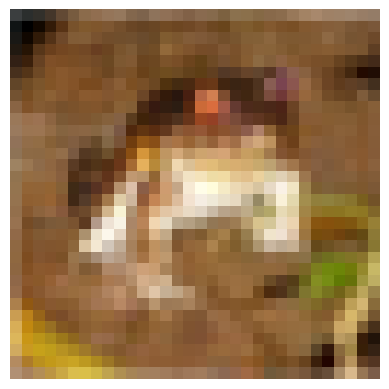

In [ ]:
# =========================================================
# --- WCZYTANIE DANYCH ---
# =========================================================
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
# przykładowy obraz
plt.imshow(x_train[0])
plt.axis('off')
plt.show()

In [ ]:
# =========================================================
# --- WSTĘPNE PRZETWARZANIE ---
# =========================================================

# Normalizacja do zakresu [0,1] i dodanie kanału (H,W,1)
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32') / 255.0

# One-hot encoding etykiet
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat  = to_categorical(y_test, num_classes)

# lista nazw klas CIFAR-10 (użyteczna w wyświetleniach)
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

In [ ]:
# =========================================================
# --- AUGMENTACJA DANYCH ---
# =========================================================

datagen = ImageDataGenerator(
    rotation_range=15,      # losowy obrót o 15 stopni
    width_shift_range=0.1,  # losowe przesunięcie w poziomie o 10% szerokości
    height_shift_range=0.1, # losowe przesunięcie w pionie o 10% wysokości
    shear_range=0.1,        # losowe ścinanie o 10%
    zoom_range=0.1,         # losowe powiększanie o 10%
    horizontal_flip=True,   # losowe odwrócenie w poziomie
    fill_mode='nearest'     # strategia wypełniania pikseli po transformacji
)

datagen.fit(x_train)

In [ ]:
# =========================================================
# --- MODEL 1 ---
# =========================================================
input_shape = (32, 32, 3)  # CIFAR-10 to 32x32 RGB

model_1 = Sequential([
    Input(shape=input_shape),

    Conv2D(64, (3,3), activation='gelu', padding='same'),
    BatchNormalization(),
    Dropout(0.1),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='gelu', padding='same'),
    BatchNormalization(),
    Dropout(0.1),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='gelu', padding='same'),
    BatchNormalization(),
    Dropout(0.1),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),
    Dense(128, activation='gelu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

In [ ]:
# =========================================================
# --- KOMPILACJA MODELU ---
# =========================================================
model_1.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_1.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,402 (513.29 KB)

 Trainable params: 130,890 (511.29 KB)

 Non-trainable params: 512 (2.00 KB)

In [ ]:
# =========================================================
# --- TRENING MODELU Z AUGMENTACJĄ ---
# =========================================================
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    mode='max',
    factor=0.1,
    patience=3,
    min_lr=1e-6
)

history = model_1.fit(
    datagen.flow(x_train, y_train_cat, batch_size=32),
    epochs=30,
    validation_data=(x_test, y_test_cat),
    callbacks=[early_stopping, reduce_lr]
)

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 53s 28ms/step - accuracy: 0.4404 - loss: 1.5436 - val_accuracy: 0.4594 - val_loss: 1.5570 - learning_rate: 0.0010
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.5684 - loss: 1.2144 - val_accuracy: 0.4880 - val_loss: 1.6408 - learning_rate: 0.0010
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6184 - loss: 1.0863 - val_accuracy: 0.6032 - val_loss: 1.2133 - learning_rate: 0.0010
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6529 - loss: 0.9946 - val_accuracy: 0.6357 - val_loss: 1.0668 - learning_rate: 0.0010
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6697 - loss: 0.9475 - val_accuracy: 0.6353 - val_loss: 1.1601 - learning_rate: 0.0010
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.6891 - loss: 0.8981 - val_accuracy: 0.6403 - val_loss: 1.0338 - learning_rate: 0.0010
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accura

In [ ]:
# =========================================================
# --- Ewaluacja modelu ---
# =========================================================
loss, accuracy = model_1.evaluate(x_test, y_test_cat, verbose=0)
print('Dokładność na zbiorze testowym:', f"{accuracy:.2f}")
print('Strata na zbiorze testowym:', f"{loss:.2f}")

Dokładność na zbiorze testowym: 0.81
Strata na zbiorze testowym: 0.56


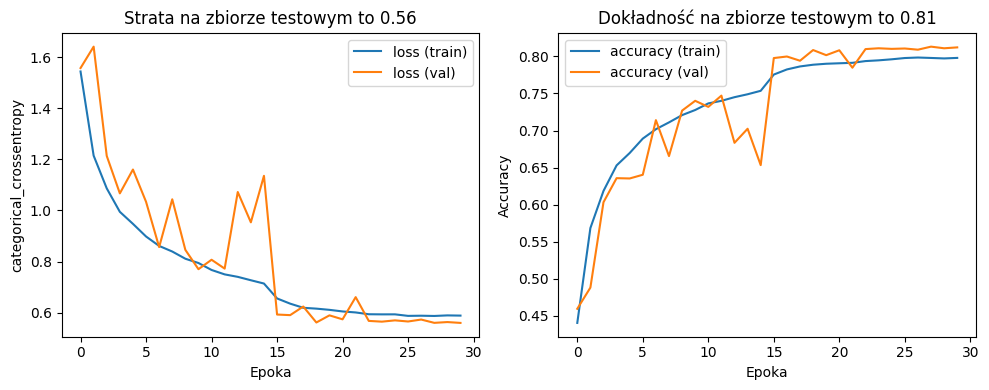

In [ ]:
# =========================================================
# --- Wizualizacja przebiegu treningu (loss) ---
# =========================================================
fig_loss_acc = plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='loss (train)')
plt.plot(history.history['val_loss'], label='loss (val)')
plt.xlabel('Epoka')
plt.ylabel('categorical_crossentropy')
plt.title(f'Strata na zbiorze testowym to {loss:.2f}')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='accuracy (train)')
plt.plot(history.history['val_accuracy'], label='accuracy (val)')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.title(f"Dokładność na zbiorze testowym to {accuracy:.2f}")
plt.legend()
plt.tight_layout()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


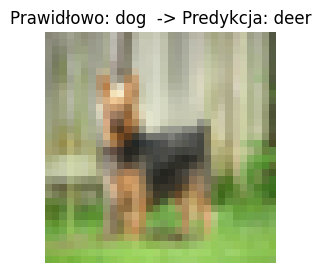

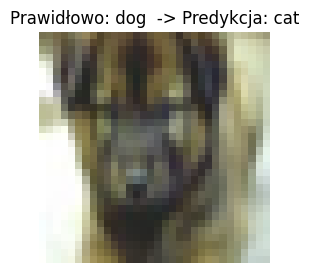

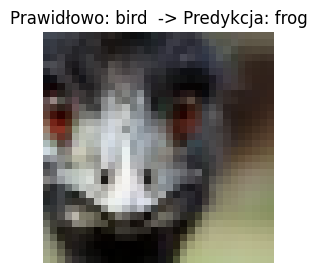

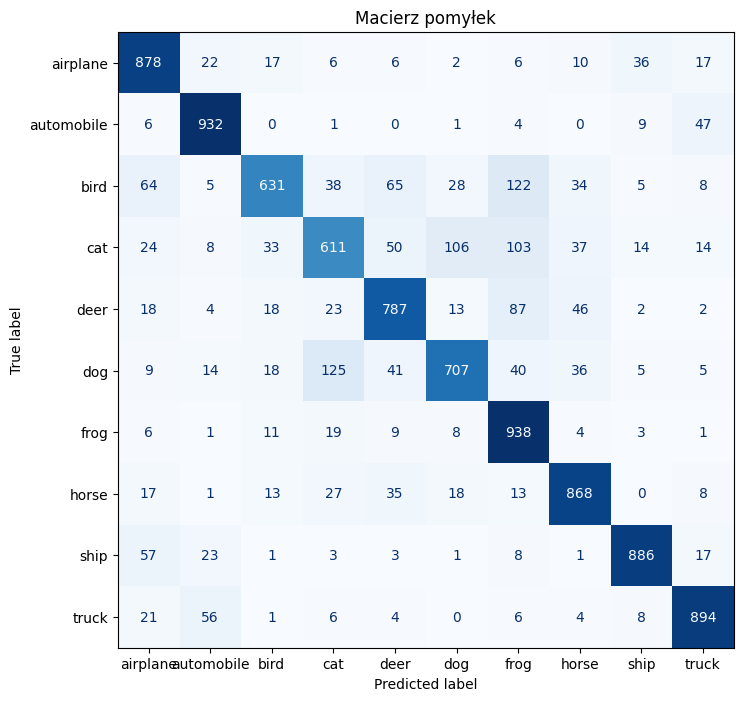

In [ ]:
# =========================================================
# --- WIZUALIZACJA BŁĘDNYCH KLASYFIKACJI I MACIERZ POMYŁEK ---
# =========================================================
# Predykcje (etykiety)
pred_probs = model_1.predict(x_test)
pred_labels = np.argmax(pred_probs, axis=1)
true_labels = np.argmax(y_test_cat, axis=1)  # lub po prostu y_test

# Indeksy błędnych klasyfikacji
incorrect_indices = np.nonzero(pred_labels != true_labels)[0]

# Wyświetlenie kilku błędnych przykładów
n_show = min(3, len(incorrect_indices))
for i in range(n_show):
    idx = incorrect_indices[i]
    plt.figure(figsize=(3,3))
    plt.imshow(x_test[idx].squeeze(), cmap='gray')
    plt.title(f"Prawidłowo: {class_names[true_labels[idx]]}  -> Predykcja: {class_names[pred_labels[idx]]}")
    plt.axis('off')
    plt.show()

# Confusion matrix
cm = confusion_matrix(true_labels, pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig_cm, ax = plt.subplots(figsize=(8,8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Macierz pomyłek')

plt.show()

In [ ]:
# =========================================================
# --- MODEL 2 ---
# =========================================================
input_shape = (32, 32, 3)  # CIFAR-10 to 32x32 RGB

model_2 = Sequential([
    Input(shape=input_shape),

    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.1),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.1),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.1),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.1),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    Dropout(0.1),
    MaxPooling2D((2,2)),

    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

In [ ]:
# =========================================================
# --- KOMPILACJA MODELU 2 ---
# =========================================================
model_2.compile(
    optimizer=Adam(learning_rate=1.0e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 2, 2, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 2, 2, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │         8,32

 Total params: 140,938 (550.54 KB)

 Trainable params: 140,362 (548.29 KB)

 Non-trainable params: 576 (2.25 KB)

In [ ]:
# =========================================================
# --- TRENING MODELU 2 Z AUGMENTACJĄ ---
# =========================================================
early_stopping_2 = EarlyStopping(
    monitor='val_accuracy',
    mode='max',
    patience=10,
    restore_best_weights=True
)

reduce_lr_2 = ReduceLROnPlateau(
    monitor='val_accuracy',
    mode='max',
    factor=0.1,
    patience=3,
    min_lr=1e-6
)

history_2 = model_2.fit(
    datagen.flow(x_train, y_train_cat, batch_size=32),
    epochs=30,
    validation_data=(x_test, y_test_cat),
    callbacks=[early_stopping_2, reduce_lr_2]
)

Epoch 1/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 29ms/step - accuracy: 0.4177 - loss: 1.6096 - val_accuracy: 0.5195 - val_loss: 1.3316 - learning_rate: 0.0010
Epoch 2/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.5430 - loss: 1.2847 - val_accuracy: 0.5631 - val_loss: 1.2170 - learning_rate: 0.0010
Epoch 3/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 24ms/step - accuracy: 0.6007 - loss: 1.1457 - val_accuracy: 0.6582 - val_loss: 0.9713 - learning_rate: 0.0010
Epoch 4/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 40s 24ms/step - accuracy: 0.6330 - loss: 1.0530 - val_accuracy: 0.5947 - val_loss: 1.1697 - learning_rate: 0.0010
Epoch 5/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6580 - loss: 0.9935 - val_accuracy: 0.6369 - val_loss: 1.1141 - learning_rate: 0.0010
Epoch 6/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accuracy: 0.6731 - loss: 0.9480 - val_accuracy: 0.6946 - val_loss: 0.8856 - learning_rate: 0.0010
Epoch 7/30
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 23ms/step - accura

In [ ]:
# =========================================================
# --- Ewaluacja modelu 2 ---
# =========================================================
loss_2, accuracy_2 = model_2.evaluate(x_test, y_test_cat, verbose=0)
print('Dokładność na zbiorze testowym dla modelu 2:', f"{accuracy_2:.2f}")
print('Strata na zbiorze testowym dla modelu 2:', f"{loss_2:.2f}")

Dokładność na zbiorze testowym dla modelu 2: 0.78
Strata na zbiorze testowym dla modelu 2: 0.65


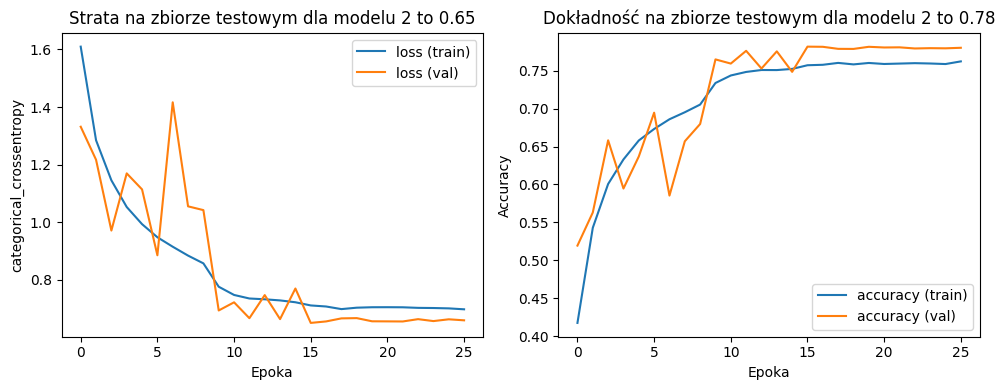

In [ ]:
# =========================================================
# --- Wizualizacja przebiegu treningu (loss) dla modelu 2 ---
# =========================================================
fig_loss_acc_2 = plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(history_2.history['loss'], label='loss (train)')
plt.plot(history_2.history['val_loss'], label='loss (val)')
plt.xlabel('Epoka')
plt.ylabel('categorical_crossentropy')
plt.title(f'Strata na zbiorze testowym dla modelu 2 to {loss_2:.2f}')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_2.history['accuracy'], label='accuracy (train)')
plt.plot(history_2.history['val_accuracy'], label='accuracy (val)')
plt.xlabel('Epoka')
plt.ylabel('Accuracy')
plt.title(f"Dokładność na zbiorze testowym dla modelu 2 to {accuracy_2:.2f}")
plt.legend()
plt.tight_layout()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


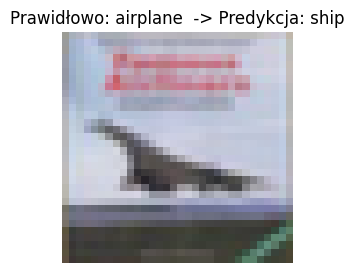

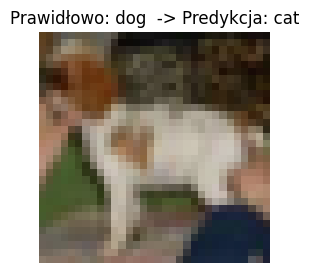

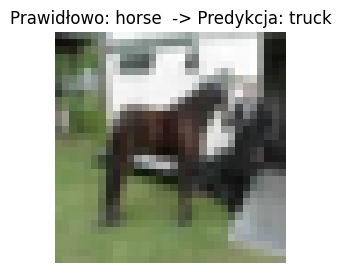

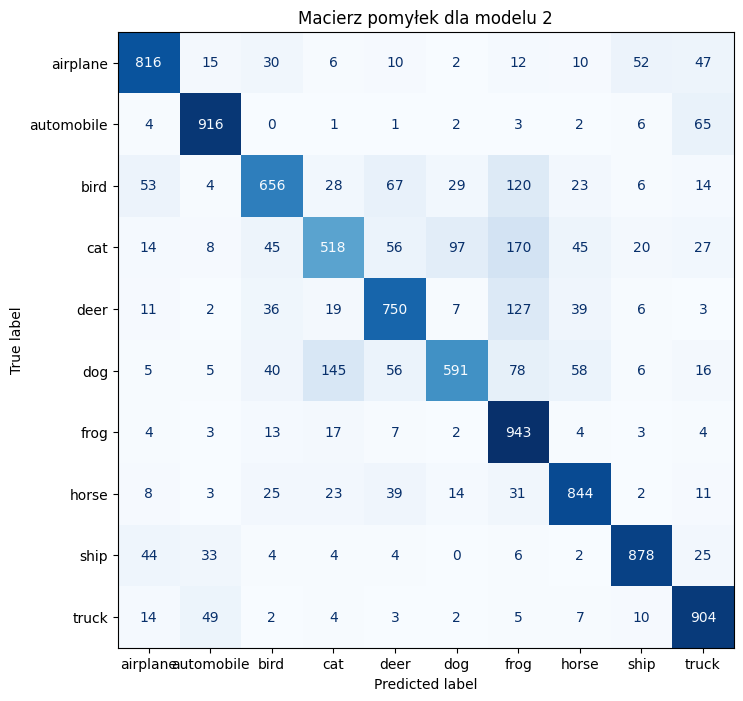

In [ ]:
# =========================================================
# --- WIZUALIZACJA BŁĘDNYCH KLASYFIKACJI I MACIERZ POMYŁEK DLA MODELU 2 ---
# =========================================================
# Predykcje (etykiety)
pred_probs_2 = model_2.predict(x_test)
pred_labels_2 = np.argmax(pred_probs_2, axis=1)
true_labels_2 = np.argmax(y_test_cat, axis=1)  # lub po prostu y_test

# Indeksy błędnych klasyfikacji
incorrect_indices_2 = np.nonzero(pred_labels_2 != true_labels_2)[0]

# Wyświetlenie kilku błędnych przykładów
n_show_2 = min(3, len(incorrect_indices_2))
for i in range(n_show_2):
    idx = incorrect_indices_2[i]
    plt.figure(figsize=(3,3))
    plt.imshow(x_test[idx].squeeze())
    plt.title(f"Prawidłowo: {class_names[true_labels_2[idx]]}  -> Predykcja: {class_names[pred_labels_2[idx]]}")
    plt.axis('off')
    plt.show()

# Confusion matrix
cm_2 = confusion_matrix(true_labels_2, pred_labels_2)
disp_2 = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=class_names)
fig_cm_2, ax_2 = plt.subplots(figsize=(8,8))
disp_2.plot(ax=ax_2, cmap='Blues', colorbar=False)
plt.title('Macierz pomyłek dla modelu 2')
plt.show()

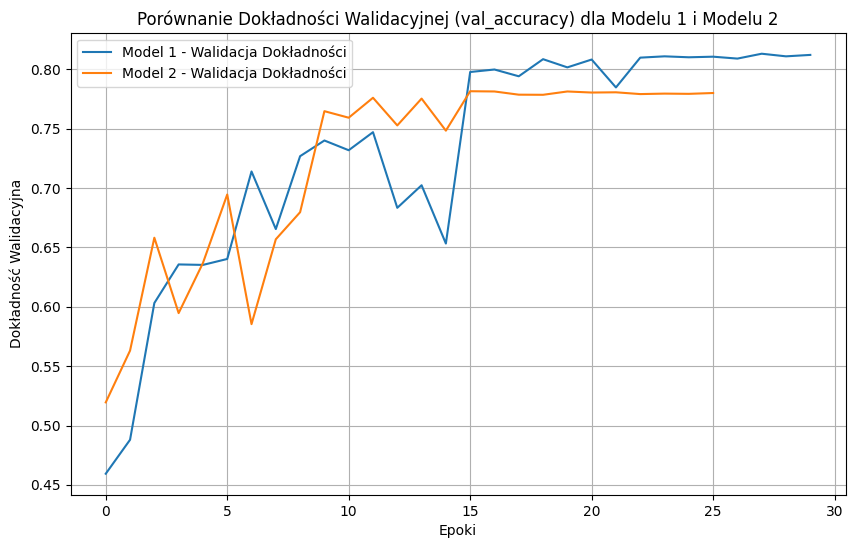

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['val_accuracy'], label='Model 1 - Walidacja Dokładności')
plt.plot(history_2.history['val_accuracy'], label='Model 2 - Walidacja Dokładności')
plt.title('Porównanie Dokładności Walidacyjnej (val_accuracy) dla Modelu 1 i Modelu 2')
plt.xlabel('Epoki')
plt.ylabel('Dokładność Walidacyjna')
plt.legend()
plt.grid(True)
plt.show()